<a href="https://colab.research.google.com/github/sushmapraveenabandi-afk/health-care-patient-analysis/blob/main/healthcare_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Patient Analysis

## Project Overview

This project analyzes 5,000 hospital patient records using Python, Pandas, Matplotlib, and Seaborn.

The analysis explores patient demographics, length of stay, admission patterns, hospital characteristics, severity of illness, admission deposits, visitors, and missing values.

# 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("HospitalSynthetic1.csv")
df.head()


,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,patientid,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,784,25,b,2,Y,4,gynecology,Q,D,4.0,91534,8.0,Trauma,Moderate,2,41-50,5356,20-Nov
1,3250,10,c,5,Z,4,gynecology,S,F,2.0,11382,15.0,Emergency,Moderate,2,21-30,4735,51-60
2,7971,26,b,2,Y,5,anesthesia,R,D,4.0,13449,8.0,Trauma,Moderate,4,71-80,4651,41-50
3,1415,23,a,6,X,4,gynecology,Q,F,3.0,125922,8.0,Emergency,Minor,4,21-30,5292,20-Nov
4,5291,9,g,9,Y,3,gynecology,R,B,3.0,96482,8.0,Trauma,Moderate,2,21-30,4769,31-40


# 2. Initial Data Inspection

In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   case_id                            5000 non-null   int64  
 1   Hospital_code                      5000 non-null   int64  
 2   Hospital_type_code                 5000 non-null   object 
 3   City_Code_Hospital                 5000 non-null   int64  
 4   Hospital_region_code               5000 non-null   object 
 5   Available Extra Rooms in Hospital  5000 non-null   int64  
 6   Department                         5000 non-null   object 
 7   Ward_Type                          5000 non-null   object 
 8   Ward_Facility_Code                 5000 non-null   object 
 9   Bed Grade                          4969 non-null   float64
 10  patientid                          5000 non-null   int64  
 11  City_Code_Patient                  4879 non-null   float

In [3]:
df.dtypes

,0
case_id,int64
Hospital_code,int64
Hospital_type_code,object
City_Code_Hospital,int64
Hospital_region_code,object
Available Extra Rooms in Hospital,int64
Department,object
Ward_Type,object
Ward_Facility_Code,object
Bed Grade,float64


In [4]:
df.shape

(5000, 18)

In [5]:
df.describe()

,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
count,5000.000000,5000.000000,5000.000000,5000.000000,4969.000000,5000.000000,4879.000000,5000.000000,5000.000000
mean,4391.690600,18.130600,4.769400,3.307000,2.914067,67547.566200,7.290428,3.485600,4620.959600
std,2797.020744,8.886244,3.130588,1.081751,0.876687,34163.476697,3.412932,1.837299,969.501843
min,1.000000,1.000000,1.000000,1.000000,1.000000,3001.000000,1.000000,2.000000,2238.000000
25%,1819.750000,10.000000,2.000000,3.000000,2.000000,36534.250000,7.000000,2.000000,3912.750000
50%,4609.500000,20.000000,5.000000,3.000000,3.000000,67169.000000,8.000000,3.000000,4647.000000
75%,6552.500000,26.000000,7.000000,4.000000,4.000000,94557.750000,8.000000,4.000000,5129.000000
max,9999.000000,32.000000,13.000000,8.000000,4.000000,131507.000000,25.000000,14.000000,8539.000000


## 3. Data Quality Check

In [6]:
df.isnull().sum()
[df.isnull().sum() > 0]

[case_id                              False
 Hospital_code                        False
 Hospital_type_code                   False
 City_Code_Hospital                   False
 Hospital_region_code                 False
 Available Extra Rooms in Hospital    False
 Department                           False
 Ward_Type                            False
 Ward_Facility_Code                   False
 Bed Grade                             True
 patientid                            False
 City_Code_Patient                     True
 Type of Admission                    False
 Severity of Illness                  False
 Visitors with Patient                False
 Age                                  False
 Admission_Deposit                    False
 Stay                                 False
 dtype: bool]

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe(include="object")

,Hospital_type_code,Hospital_region_code,Department,Ward_Type,Ward_Facility_Code,Type of Admission,Severity of Illness,Age,Stay
count,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,7,3,5,5,6,3,3,10,11
top,a,Y,gynecology,R,F,Trauma,Moderate,41-50,20-Nov
freq,1983,2051,3629,1989,1702,2699,3587,1674,1270


In [9]:
print(df["Bed Grade"].value_counts(dropna=False))
print()


Bed Grade
3.0    1705
2.0    1550
4.0    1517
1.0     197
NaN      31
Name: count, dtype: int64



In [10]:
print(df["City_Code_Patient"].value_counts(dropna=False))

City_Code_Patient
8.0     2861
4.0      360
1.0      359
2.0      243
5.0      228
9.0      213
7.0      202
NaN      121
11.0     101
14.0      96
10.0      79
15.0      49
22.0      31
23.0      29
21.0      17
20.0       5
24.0       4
25.0       1
19.0       1
Name: count, dtype: int64


In [11]:
df["Age"].value_counts(dropna=False)

,count
Age,
41-50,1674
61-70,632
31-40,630
21-30,574
51-60,549
71-80,492
20-Nov,244
81-90,148
91-100,37


## 4. Patient Demographics

In [12]:
df["Age"].unique()

array(['41-50', '21-30', '71-80', '31-40', '61-70', '51-60', '20-Nov',
       '81-90', '91-100', '0-10'], dtype=object)

In [13]:
df["Age"]=df["Age"].fillna("unknown")
df["Age"].value_counts(dropna=False)

,count
Age,
41-50,1674
61-70,632
31-40,630
21-30,574
51-60,549
71-80,492
20-Nov,244
81-90,148
91-100,37


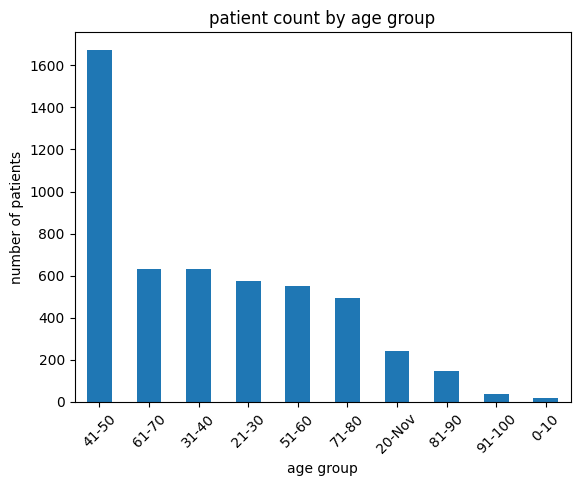

In [49]:
df["Age"].value_counts().plot(kind="bar")
plt.title("patient count by age group")
plt.xlabel("age group")
plt.ylabel("number of patients")
plt.savefig("patient_count_by_age.png")
plt.xticks(rotation=45)
plt.show()

 ## 5. Length of Stay Analysis

In [15]:
df["Stay"].value_counts(dropna=False)

,count
Stay,
20-Nov,1270
21-30,1088
31-40,910
51-60,844
0-10,233
71-80,176
41-50,163
More than 100 Days,132
81-90,77


In [16]:
df["Stay"]=df["Stay"].replace("20-Nov","unknown")

In [17]:
df["Stay"].value_counts(dropna=False)

,count
Stay,
unknown,1270
21-30,1088
31-40,910
51-60,844
0-10,233
71-80,176
41-50,163
More than 100 Days,132
81-90,77


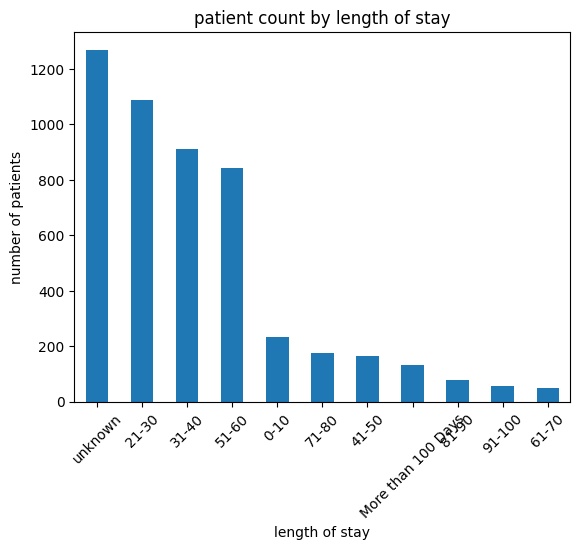

In [18]:
df["Stay"].value_counts().plot(kind="bar")
plt.title("patient count by length of stay")
plt.xlabel("length of stay")
plt.ylabel("number of patients")
plt.xticks(rotation=45)
plt.savefig("length_of_stay.png")
plt.show()

In [19]:
df[["Age","Stay"]].isnull().sum()

,0
Age,0
Stay,0


## 6. Patient and Admission Analysis

 6.1 severity of ilness of patients analysis

In [20]:
df["Department"].value_counts( dropna=False)

,count
Department,
gynecology,3629
anesthesia,778
radiotherapy,480
TB & Chest disease,95
surgery,18


In [21]:
df["Type of Admission"].value_counts()


,count
Type of Admission,
Trauma,2699
Emergency,1866
Urgent,435


In [22]:
df["Severity of Illness"].value_counts()

,count
Severity of Illness,
Moderate,3587
Extreme,751
Minor,662


In [23]:
pd.crosstab(df["Type of Admission"], df["Severity of Illness"])


Severity of Illness,Extreme,Minor,Moderate
Type of Admission,,,
Emergency,289,263,1314
Trauma,410,341,1948
Urgent,52,58,325


In [24]:
pd.crosstab(df["Type of Admission"],df["Severity of Illness"],normalize="index")*100

Severity of Illness,Extreme,Minor,Moderate
Type of Admission,,,
Emergency,15.487674,14.094319,70.418006
Trauma,15.190811,12.634309,72.174880
Urgent,11.954023,13.333333,74.712644


In [25]:
pd.crosstab(
    df["Type of Admission"],
    df["Severity of Illness"],
    normalize="index"
).mul(100).round(2)


Severity of Illness,Extreme,Minor,Moderate
Type of Admission,,,
Emergency,15.49,14.09,70.42
Trauma,15.19,12.63,72.17
Urgent,11.95,13.33,74.71


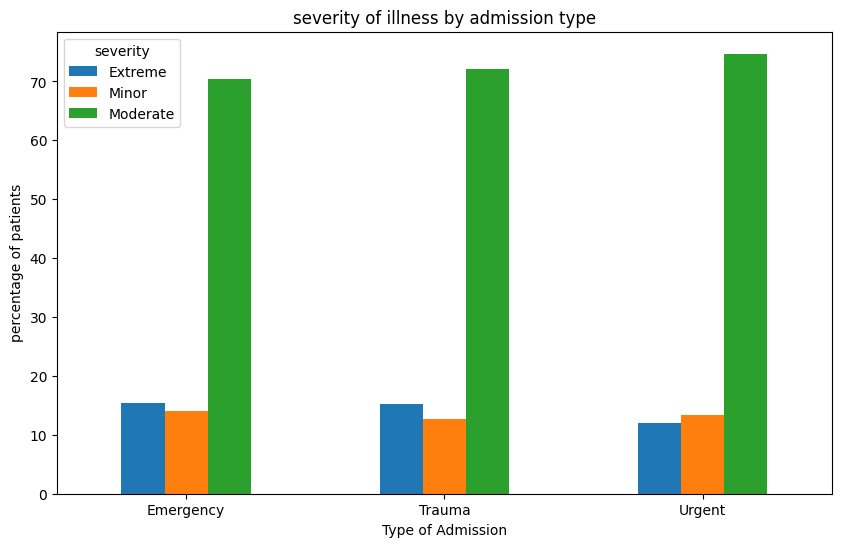

In [26]:
Severity_by_admissiontype=pd.crosstab(df["Type of Admission"],df["Severity of Illness"],normalize="index")*100
Severity_by_admissiontype.plot(kind="bar",figsize=(10,6))
plt.title("severity of illness by admission type")
plt.xlabel("Type of Admission")
plt.ylabel("percentage of patients")
plt.xticks(rotation=0)
plt.legend(title="severity")
plt.savefig("severity_by_admission_type.png")
plt.show()

In [27]:
pd.crosstab(df["Department"],df["Severity of Illness"])

Severity of Illness,Extreme,Minor,Moderate
Department,,,
TB & Chest disease,5,8,82
anesthesia,97,121,560
gynecology,570,483,2576
radiotherapy,79,49,352
surgery,0,1,17


In [28]:
pd.crosstab(df["Department"],df["Severity of Illness"],normalize="index") * 100

Severity of Illness,Extreme,Minor,Moderate
Department,,,
TB & Chest disease,5.263158,8.421053,86.315789
anesthesia,12.467866,15.552699,71.979434
gynecology,15.706806,13.309452,70.983742
radiotherapy,16.458333,10.208333,73.333333
surgery,0.000000,5.555556,94.444444


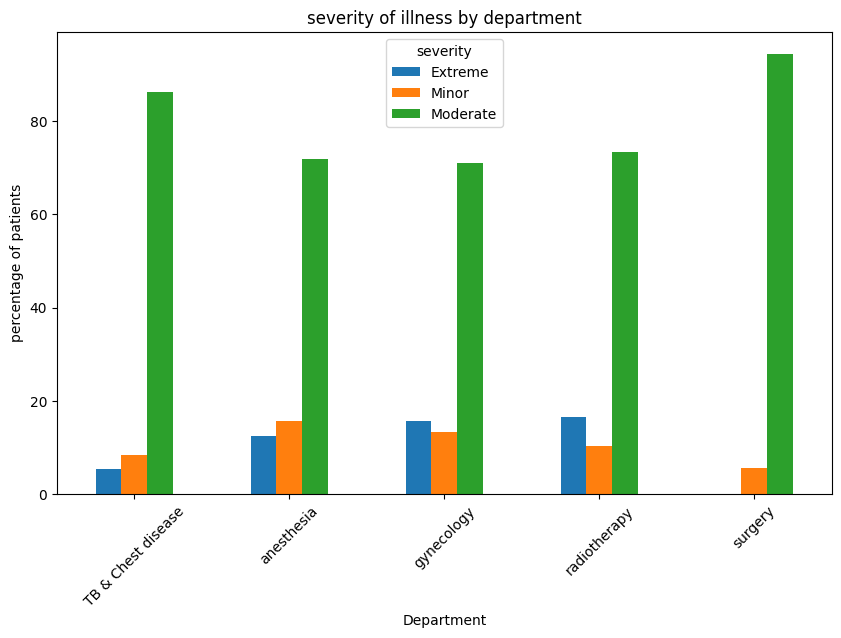

In [29]:
Severity_by_department=pd.crosstab(df["Department"],df["Severity of Illness"],normalize="index")*100
Severity_by_department.plot(kind="bar",figsize=(10,6))
plt.title("severity of illness by department")
plt.xlabel("Department")
plt.ylabel("percentage of patients")
plt.xticks(rotation=45)
plt.legend(title="severity")
plt.savefig("severity_of_illness_by_department.png")
plt.show()

In [30]:
df["Visitors with Patient"].describe()

,Visitors with Patient
count,5000.000000
mean,3.485600
std,1.837299
min,2.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,14.000000


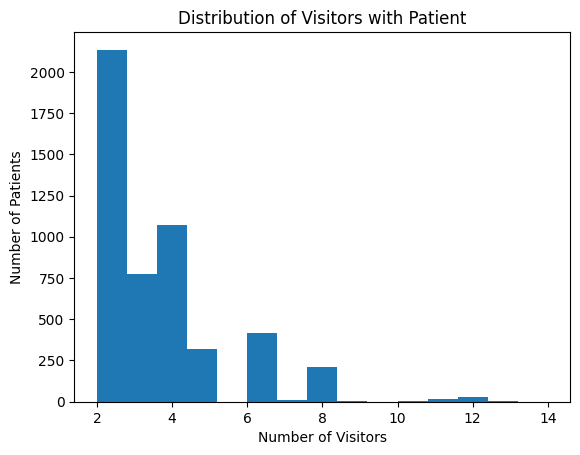

In [31]:
df["Visitors with Patient"].plot(kind="hist",bins=15)

plt.title("Distribution of Visitors with Patient")
plt.xlabel("Number of Visitors")
plt.ylabel("Number of Patients")
plt.savefig("visitors_with_patients.png")
plt.show()

In [32]:
df["Admission_Deposit"].describe()

,Admission_Deposit
count,5000.000000
mean,4620.959600
std,969.501843
min,2238.000000
25%,3912.750000
50%,4647.000000
75%,5129.000000
max,8539.000000


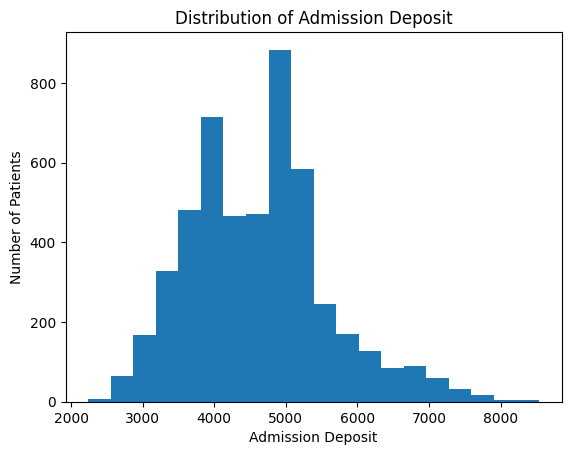

In [33]:
df["Admission_Deposit"].plot(kind="hist", bins=20)
plt.title("Distribution of Admission Deposit")
plt.xlabel("Admission Deposit")
plt.ylabel("Number of Patients")
plt.savefig("admission_deposit.png")
plt.show()

In [34]:
df["Bed Grade"].value_counts(dropna=False)

,count
Bed Grade,
3.0,1705
2.0,1550
4.0,1517
1.0,197
NaN,31


In [35]:
df["Bed Grade"].isnull().sum()

np.int64(31)

In [36]:
df.isnull().sum()

,0
case_id,0
Hospital_code,0
Hospital_type_code,0
City_Code_Hospital,0
Hospital_region_code,0
Available Extra Rooms in Hospital,0
Department,0
Ward_Type,0
Ward_Facility_Code,0
Bed Grade,31


In [37]:
df["City_Code_Hospital"].describe()

,City_Code_Hospital
count,5000.000000
mean,4.769400
std,3.130588
min,1.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,13.000000


In [38]:
df["City_Code_Patient"].isnull().sum()

np.int64(121)

In [39]:
df["City_Code_Hospital"].value_counts()

,count
City_Code_Hospital,
1,878
2,870
6,657
5,562
7,538
9,487
3,430
11,275
4,201


In [40]:
df[df["City_Code_Patient"].isnull()][["City_Code_Patient", "City_Code_Hospital"]].head(10)

,City_Code_Patient,City_Code_Hospital
21,NaN,5
44,NaN,1
115,NaN,1
143,NaN,1
173,NaN,2
272,NaN,6
303,NaN,2
355,NaN,2
468,NaN,1
539,NaN,1


In [41]:
df["Bed Grade"].isnull().mean() * 100

np.float64(0.62)

In [42]:
pd.crosstab(df["Hospital_type_code"], df["Severity of Illness"])

Severity of Illness,Extreme,Minor,Moderate
Hospital_type_code,,,
a,291,293,1399
b,216,141,833
c,58,74,647
d,36,49,246
e,88,73,304
f,47,26,83
g,15,6,75


In [43]:
pd.crosstab(
    df["Hospital_type_code"],
    df["Severity of Illness"],
    normalize="index"
) * 100

Severity of Illness,Extreme,Minor,Moderate
Hospital_type_code,,,
a,14.674735,14.775593,70.549672
b,18.151261,11.848739,70.000000
c,7.445443,9.499358,83.055199
d,10.876133,14.803625,74.320242
e,18.924731,15.698925,65.376344
f,30.128205,16.666667,53.205128
g,15.625000,6.250000,78.125000


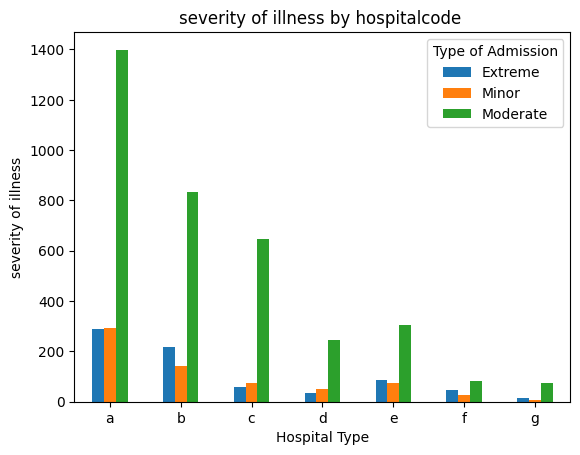

In [44]:
pd.crosstab(
    df["Hospital_type_code"],
    df["Severity of Illness"],
).plot(kind="bar")

plt.title("severity of illness by hospitalcode ")
plt.xlabel("Hospital Type")
plt.ylabel("severity of illness")
plt.xticks(rotation=0)
plt.legend(title="Type of Admission")
plt.savefig("hospital_type_by_severity_of_illness.png")
plt.show()

In [45]:
pd.crosstab(
    df["Hospital_type_code"],
    df["Type of Admission"]
).sum().sum()

np.int64(5000)

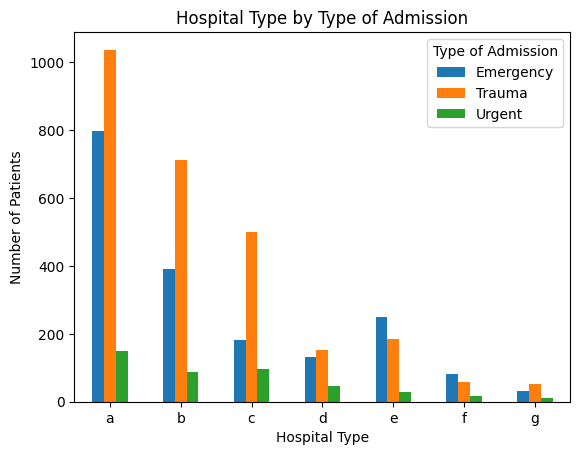

In [46]:
pd.crosstab(
    df["Hospital_type_code"],
    df["Type of Admission"]
).plot(kind="bar")

plt.title("Hospital Type by Type of Admission")
plt.xlabel("Hospital Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="Type of Admission")
plt.savefig("hospital_type_by_admission_type.png")
plt.show()

In [47]:
pd.crosstab(
    df["Ward_Type"],
    df["Severity of Illness"]
)

Severity of Illness,Extreme,Minor,Moderate
Ward_Type,,,
P,17,11,92
Q,263,179,943
R,258,279,1452
S,207,191,1080
T,6,2,20


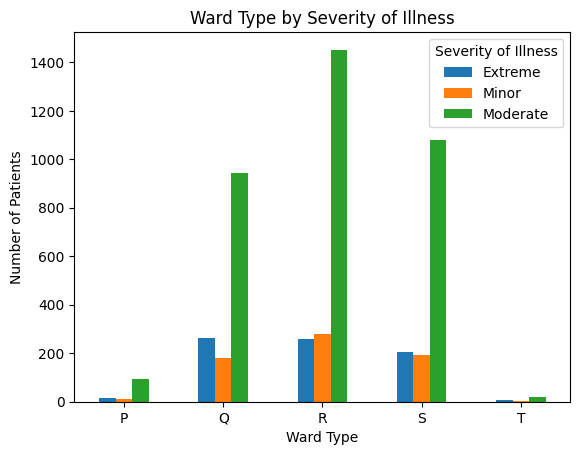

In [48]:
pd.crosstab(
    df["Ward_Type"],
    df["Severity of Illness"]
).plot(kind="bar")

plt.title("Ward Type by Severity of Illness")
plt.xlabel("Ward Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.legend(title="Severity of Illness")

plt.savefig("ward_type_severity.png")
plt.show()
